<a href="https://colab.research.google.com/github/TimofeyProtasov/diploma/blob/main/days/third_graphics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
def load_all_results(save_dir: str, path="results_train_*.csv") -> pd.DataFrame:
    all_files = Path(save_dir).glob(path)
    df_list = []
    for file in all_files:
        df = pd.read_csv(file)
        df_list.append(df)
    if df_list:
        return pd.concat(df_list, ignore_index=True)
    else:
        return pd.DataFrame()


# loha gold


In [3]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_third", "results_train_*_loha_config.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100           17.596416                         1.45   
1         300           17.596416                         1.45   
2         500           17.596416                         1.45   
3         700           17.596416                         1.45   

   train_time_min  train_peak_memory_gb    f1  evaluate_f1_time_min  \
0            0.90                 10.06  0.00                  1.77   
1            2.60                 10.13  0.06                  2.84   
2            4.37                 10.13  0.37                  4.24   
3            6.15                 10.13  0.36                  2.90   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        1.76        2.46                          0.09  ...   
1                        1.72        1.94                          0.09  ...   
2                        1.70        1.57                          0.09  

In [4]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10, 12, 14]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [5]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.00,2.69,2.07,1.76,0.09,3.48,0.90,10.06
1,100.0,6,0.00,2.61,2.06,1.76,0.09,3.48,0.90,10.06
2,100.0,8,0.00,2.56,2.21,1.76,0.09,3.48,0.90,10.06
3,100.0,10,0.00,2.52,2.01,1.76,0.09,3.48,0.90,10.06
4,100.0,12,0.00,2.49,1.93,1.76,0.09,3.48,0.90,10.06
5,100.0,14,0.00,2.46,1.77,1.76,0.09,3.48,0.90,10.06
6,300.0,4,0.00,2.19,2.71,1.72,0.09,3.23,2.60,10.13
7,300.0,6,0.00,2.10,3.20,1.72,0.09,3.23,2.60,10.13
8,300.0,8,0.04,2.05,2.85,1.72,0.09,3.23,2.60,10.13
9,300.0,10,0.02,2.00,2.98,1.72,0.09,3.23,2.60,10.13


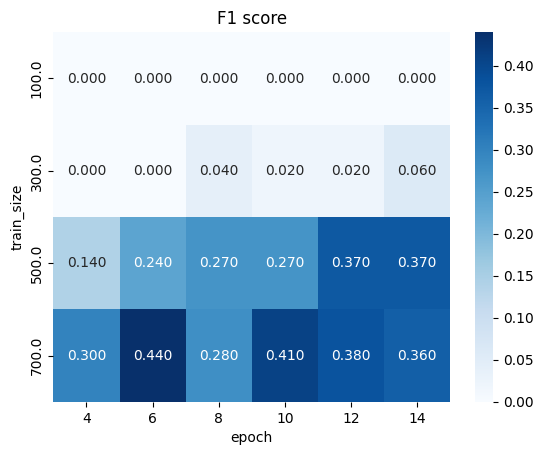

In [6]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


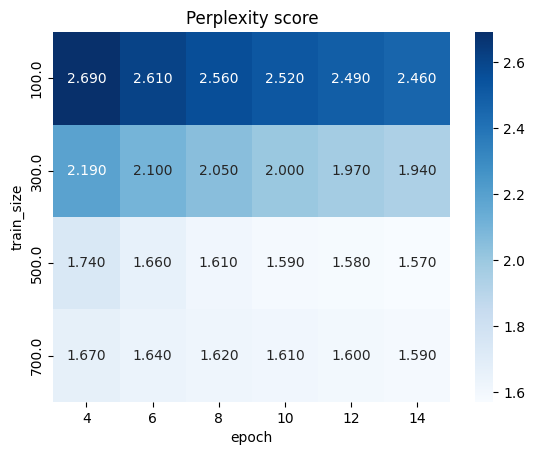

In [7]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


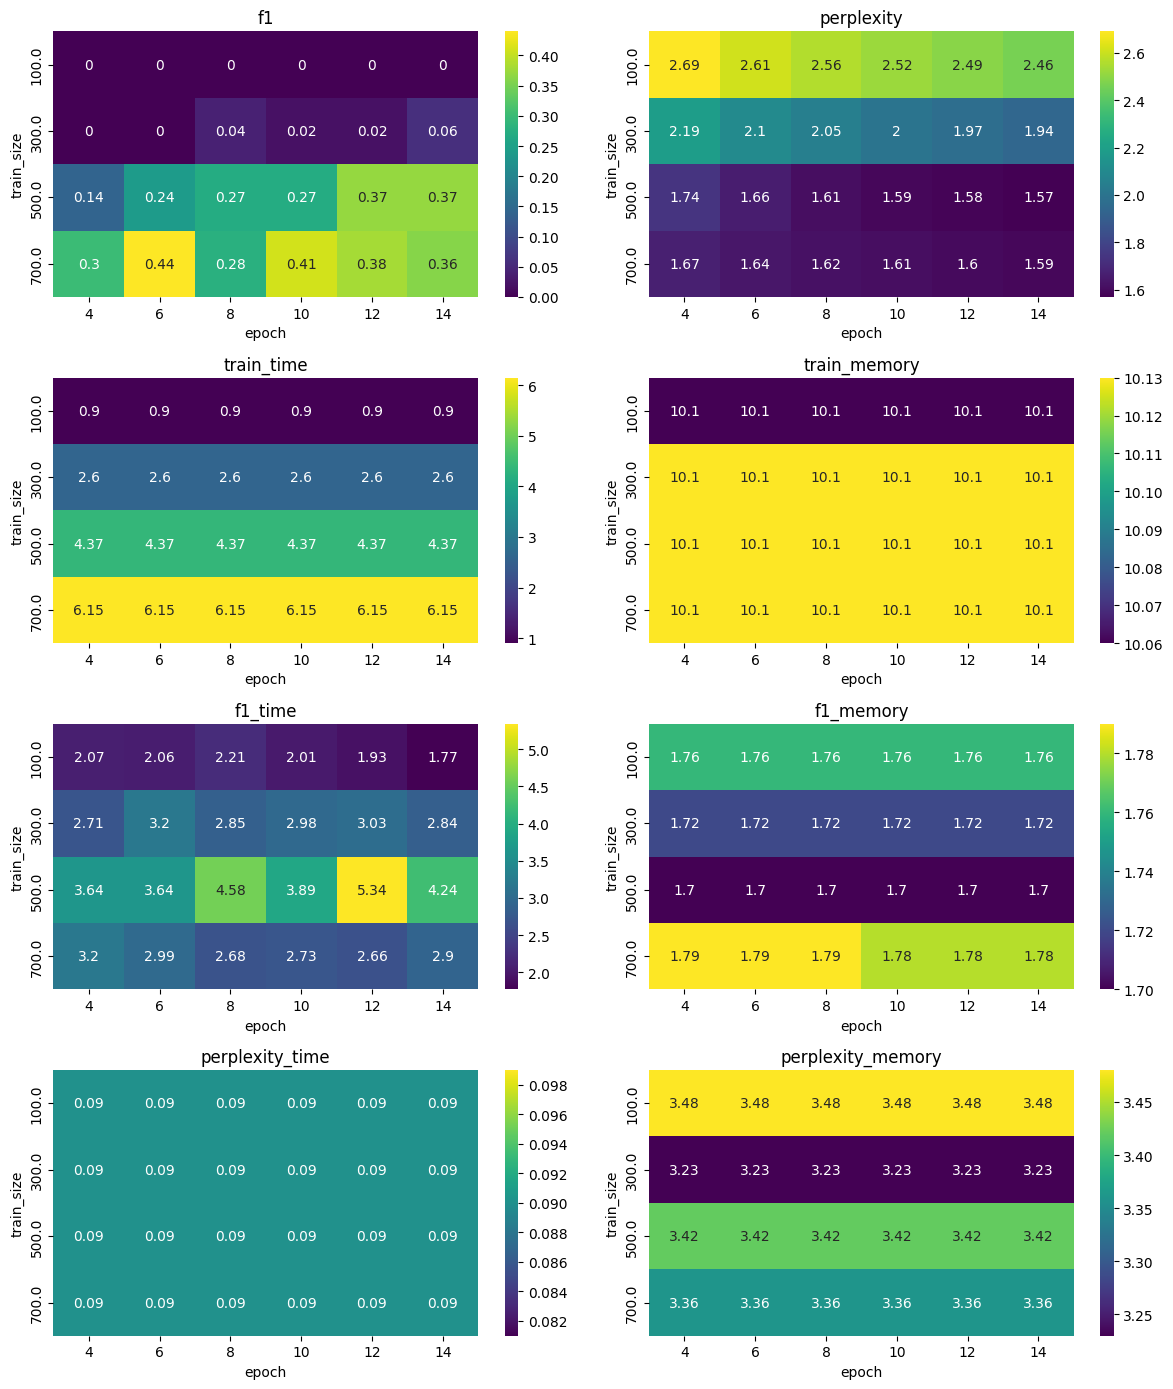

In [8]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

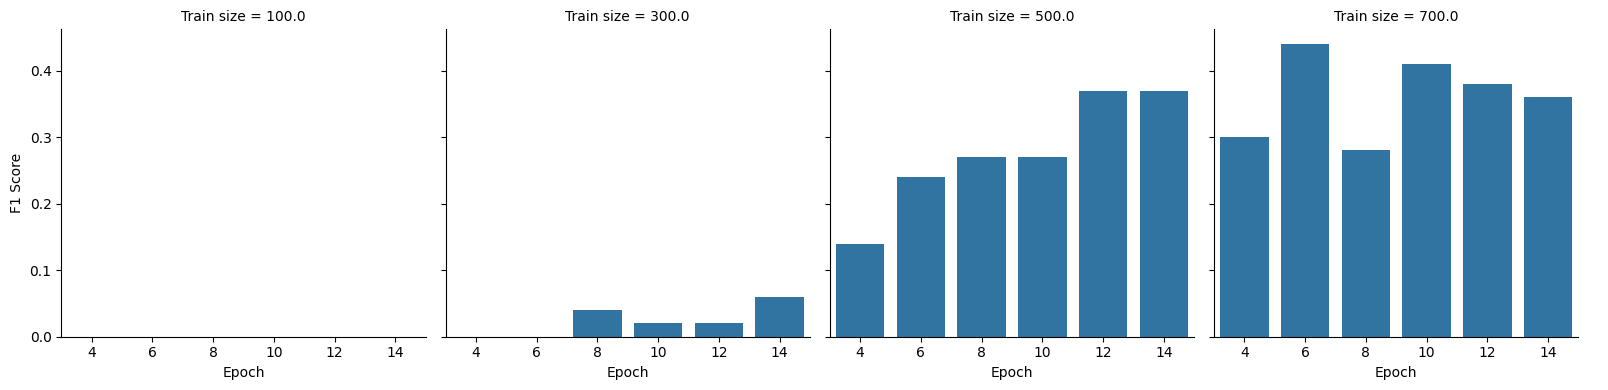

In [9]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

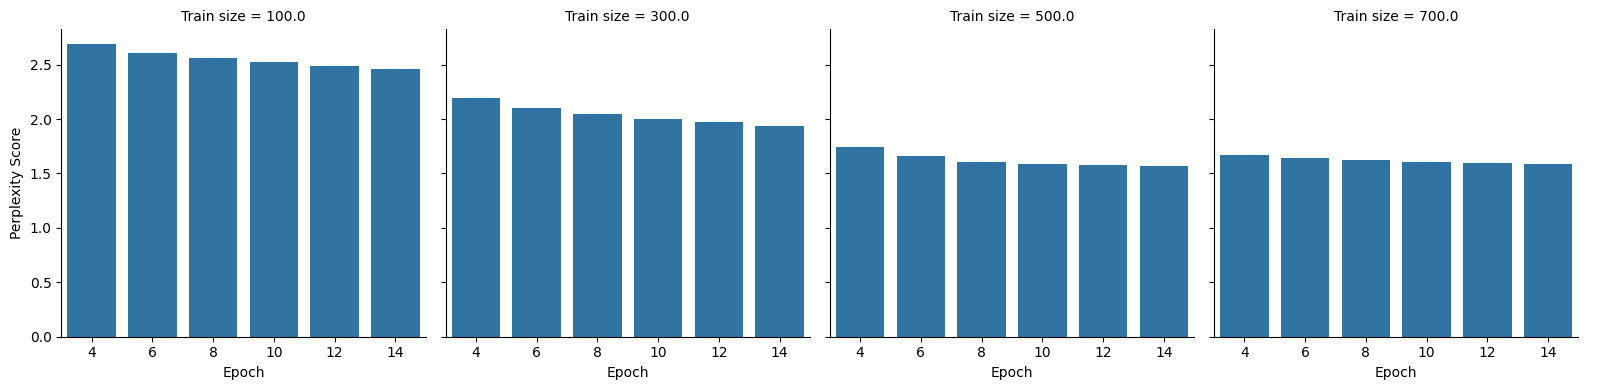

In [10]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

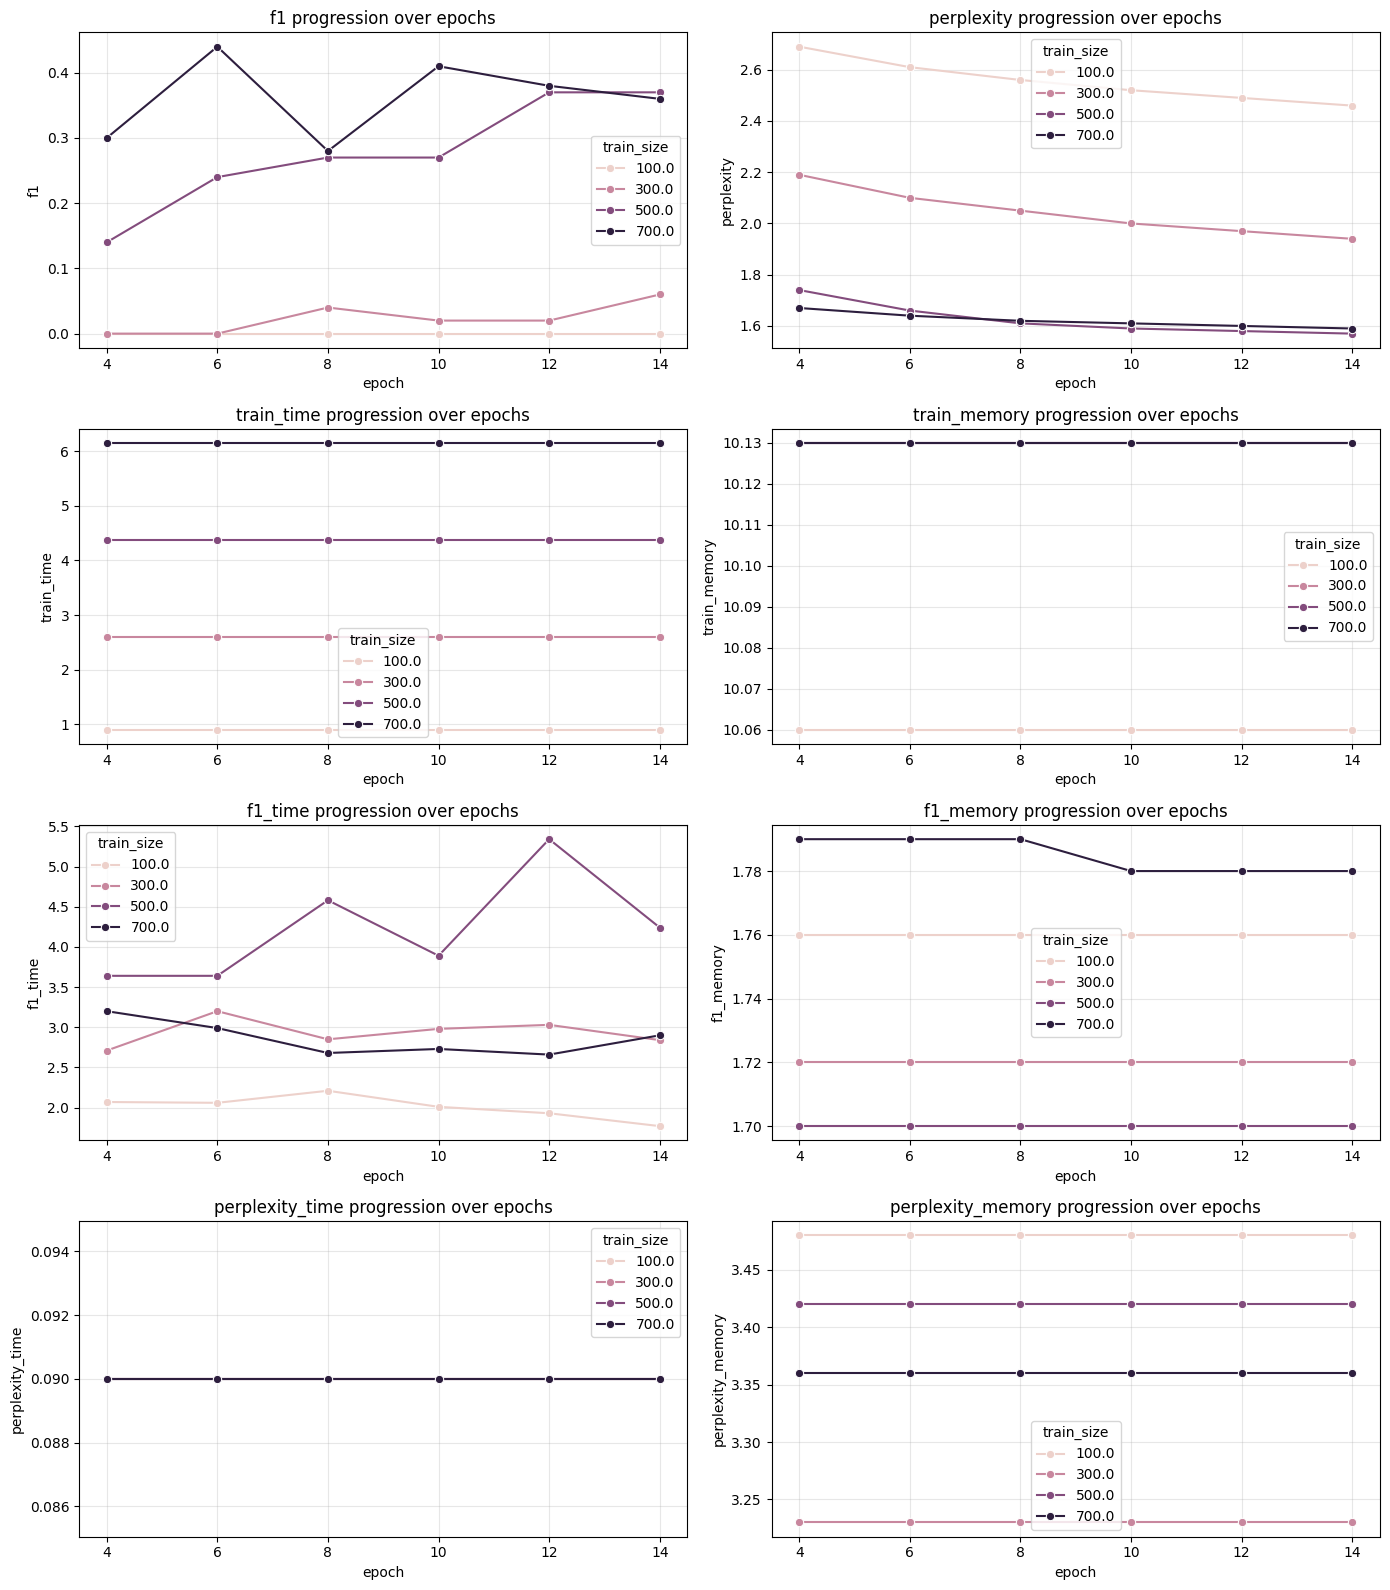

In [11]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# loha 0.8



In [12]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_third_oracle", "results_train_*_loha_config_oracle.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100           17.596416                         1.45   
1         300           17.596416                         1.45   
2         500           17.596416                         1.45   
3         700           17.596416                         1.45   

   train_time_min  train_peak_memory_gb    f1  evaluate_f1_time_min  \
0            0.90                 10.06  0.00                  1.91   
1            2.63                 10.13  0.02                  3.41   
2            4.40                 10.13  0.30                  3.24   
3            6.13                 10.13  0.44                  2.49   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        1.76        2.69                          0.09  ...   
1                        1.66        2.25                          0.09  ...   
2                        1.70        1.84                          0.09  

In [13]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10, 12, 14]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [14]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.00,2.95,2.13,1.76,0.09,3.46,0.90,10.06
1,100.0,6,0.00,2.86,2.21,1.76,0.09,3.46,0.90,10.06
2,100.0,8,0.00,2.80,2.11,1.76,0.09,3.46,0.90,10.06
3,100.0,10,0.00,2.76,1.93,1.76,0.09,3.46,0.90,10.06
4,100.0,12,0.00,2.72,1.93,1.76,0.09,3.46,0.90,10.06
5,100.0,14,0.00,2.69,1.91,1.76,0.09,3.46,0.90,10.06
6,300.0,4,0.00,2.52,2.85,1.66,0.09,3.32,2.63,10.13
7,300.0,6,0.00,2.42,3.98,1.66,0.09,3.32,2.63,10.13
8,300.0,8,0.02,2.36,4.00,1.66,0.09,3.32,2.63,10.13
9,300.0,10,0.00,2.32,4.05,1.66,0.09,3.32,2.63,10.13


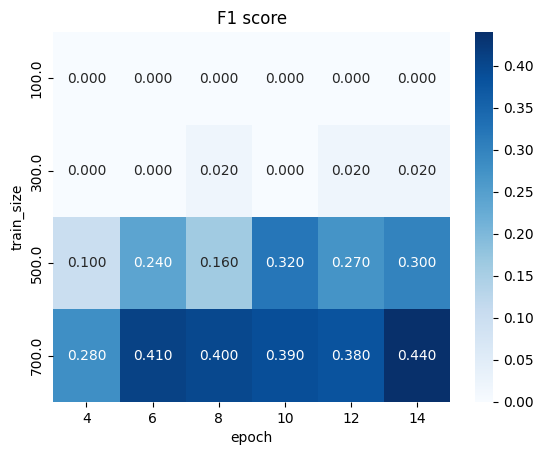

In [15]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


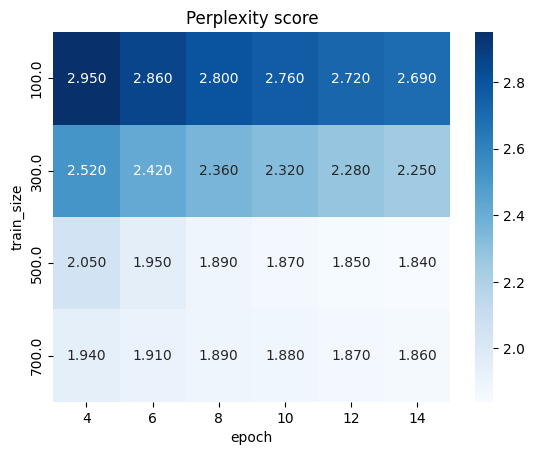

In [16]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


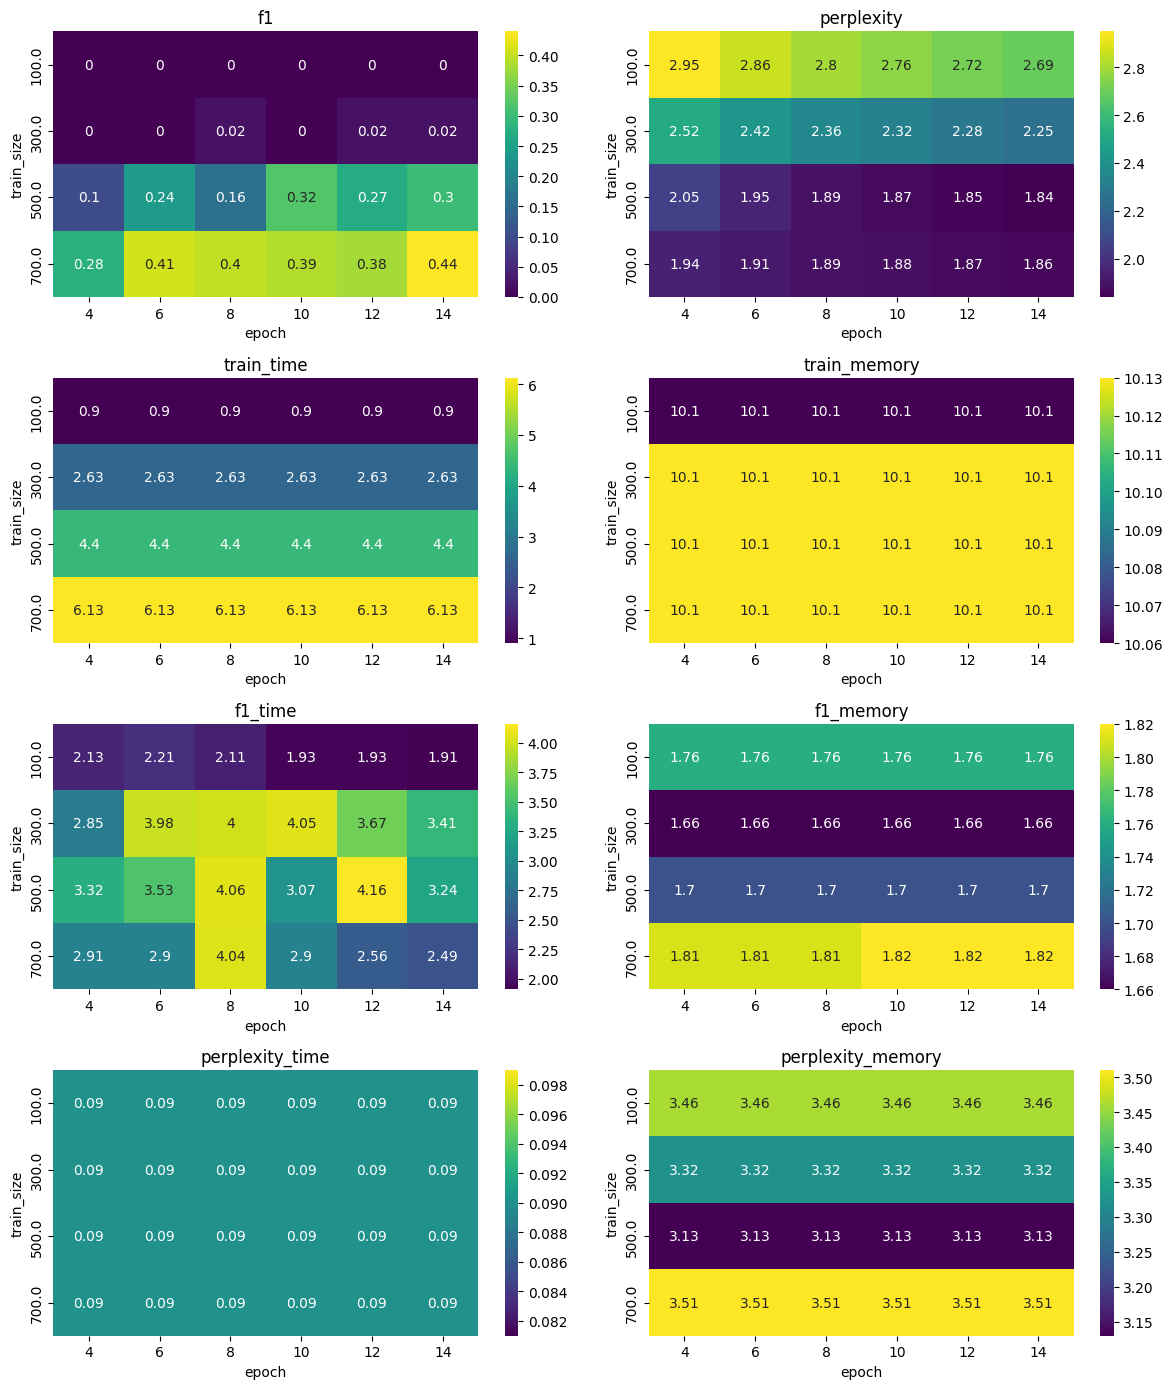

In [17]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

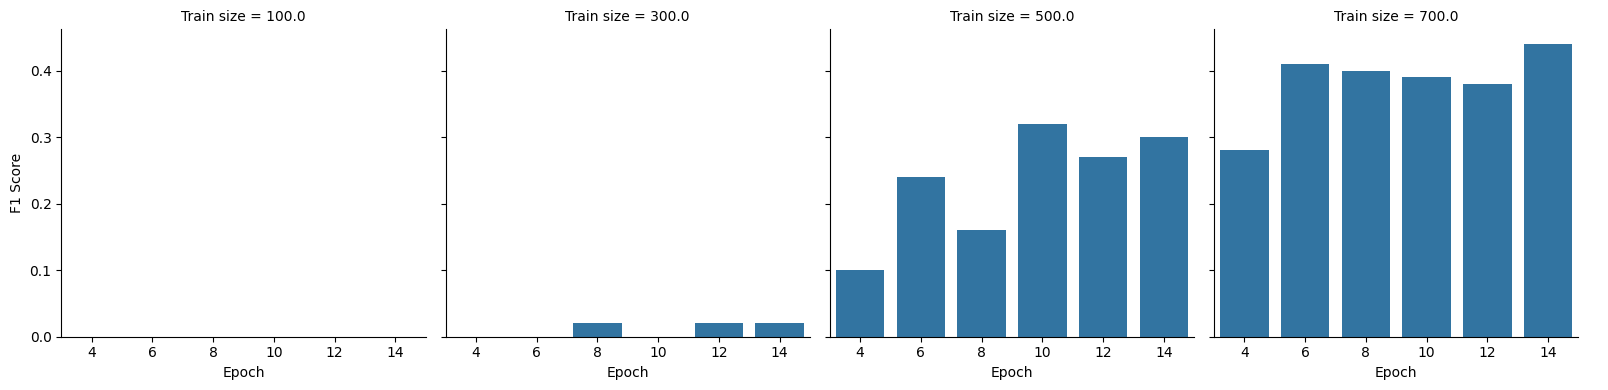

In [18]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

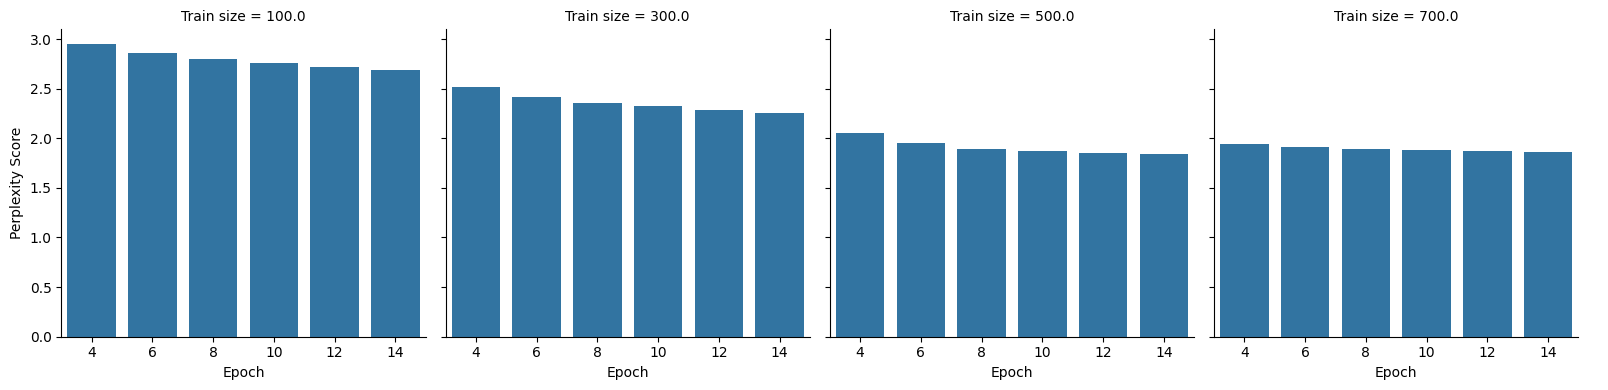

In [19]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

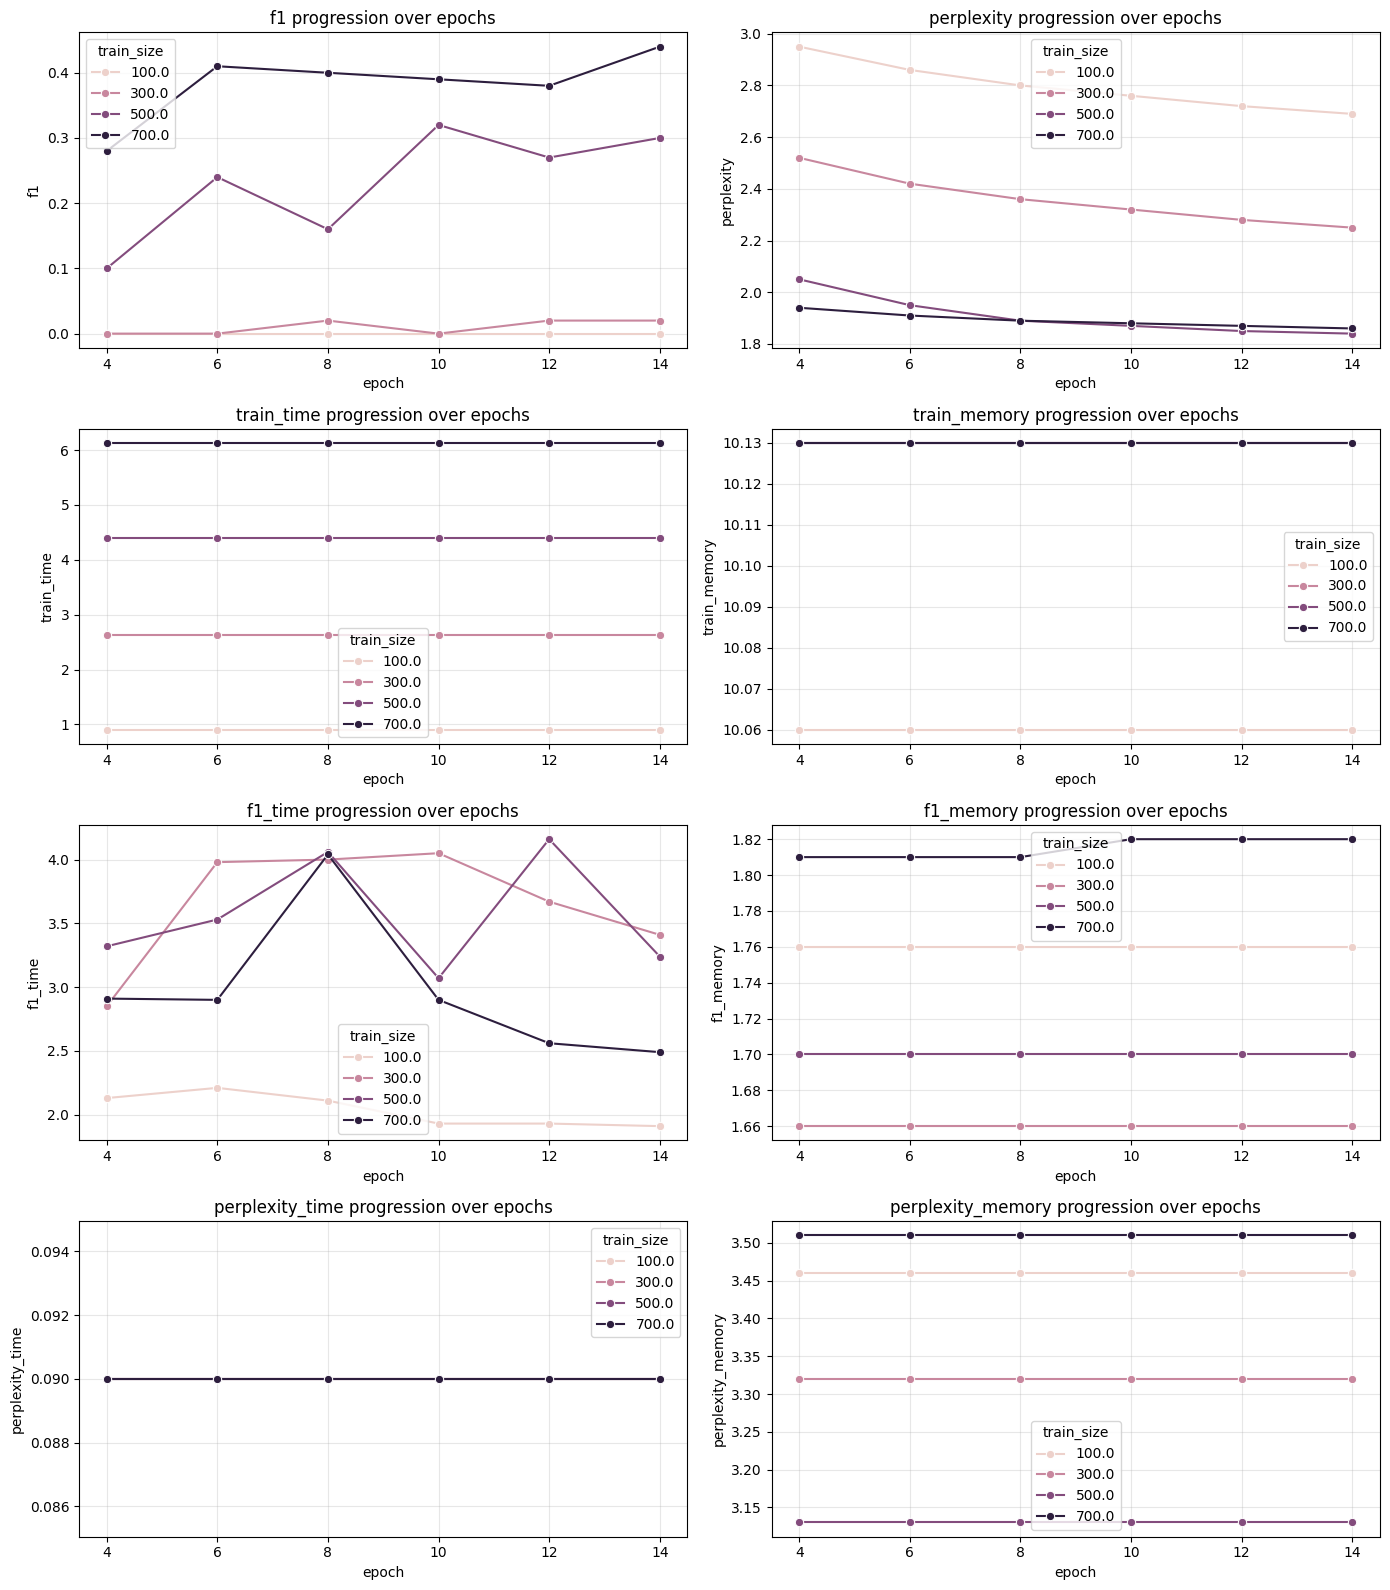

In [20]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# prompt_tuning gold


In [21]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_third", "results_train_*_prompt_tuning_config.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100                 0.0                         1.43   
1         300                 0.0                         1.45   
2         500                 0.0                         1.45   
3         700                 0.0                         1.45   

   train_time_min  train_peak_memory_gb   f1  evaluate_f1_time_min  \
0            0.58                 10.01  0.0                  0.36   
1            1.67                 10.01  0.0                  0.44   
2            2.82                 10.01  0.0                  0.39   
3            3.95                 10.01  0.0                  0.28   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        1.34        3.01                          0.04  ...   
1                        1.32        3.49                          0.04  ...   
2                        1.31        2.96                          0.04  ...  

In [22]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10, 12, 14]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [23]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.0,3.02,0.34,1.34,0.04,3.29,0.58,10.01
1,100.0,6,0.0,3.01,0.35,1.34,0.04,3.29,0.58,10.01
2,100.0,8,0.0,3.01,0.34,1.34,0.04,3.29,0.58,10.01
3,100.0,10,0.0,3.01,0.38,1.34,0.04,3.29,0.58,10.01
4,100.0,12,0.0,3.00,0.33,1.34,0.04,3.29,0.58,10.01
5,100.0,14,0.0,3.01,0.36,1.34,0.04,3.29,0.58,10.01
6,300.0,4,0.0,3.59,0.41,1.32,0.04,3.05,1.67,10.01
7,300.0,6,0.0,3.56,0.51,1.31,0.04,3.05,1.67,10.01
8,300.0,8,0.0,3.54,0.51,1.31,0.04,3.05,1.67,10.01
9,300.0,10,0.0,3.51,0.43,1.32,0.04,3.05,1.67,10.01


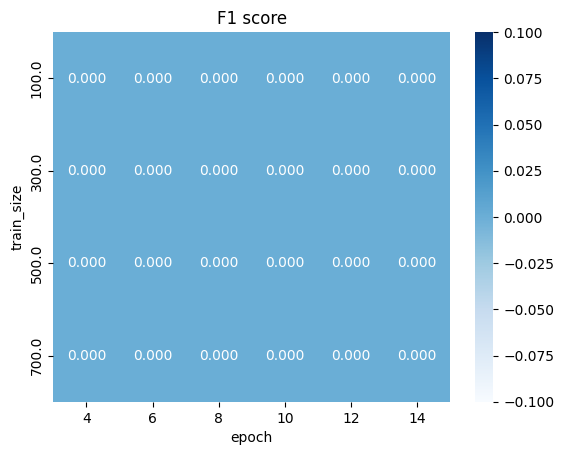

In [24]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


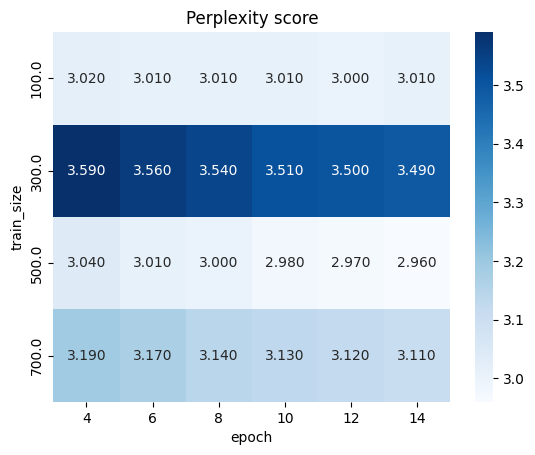

In [25]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


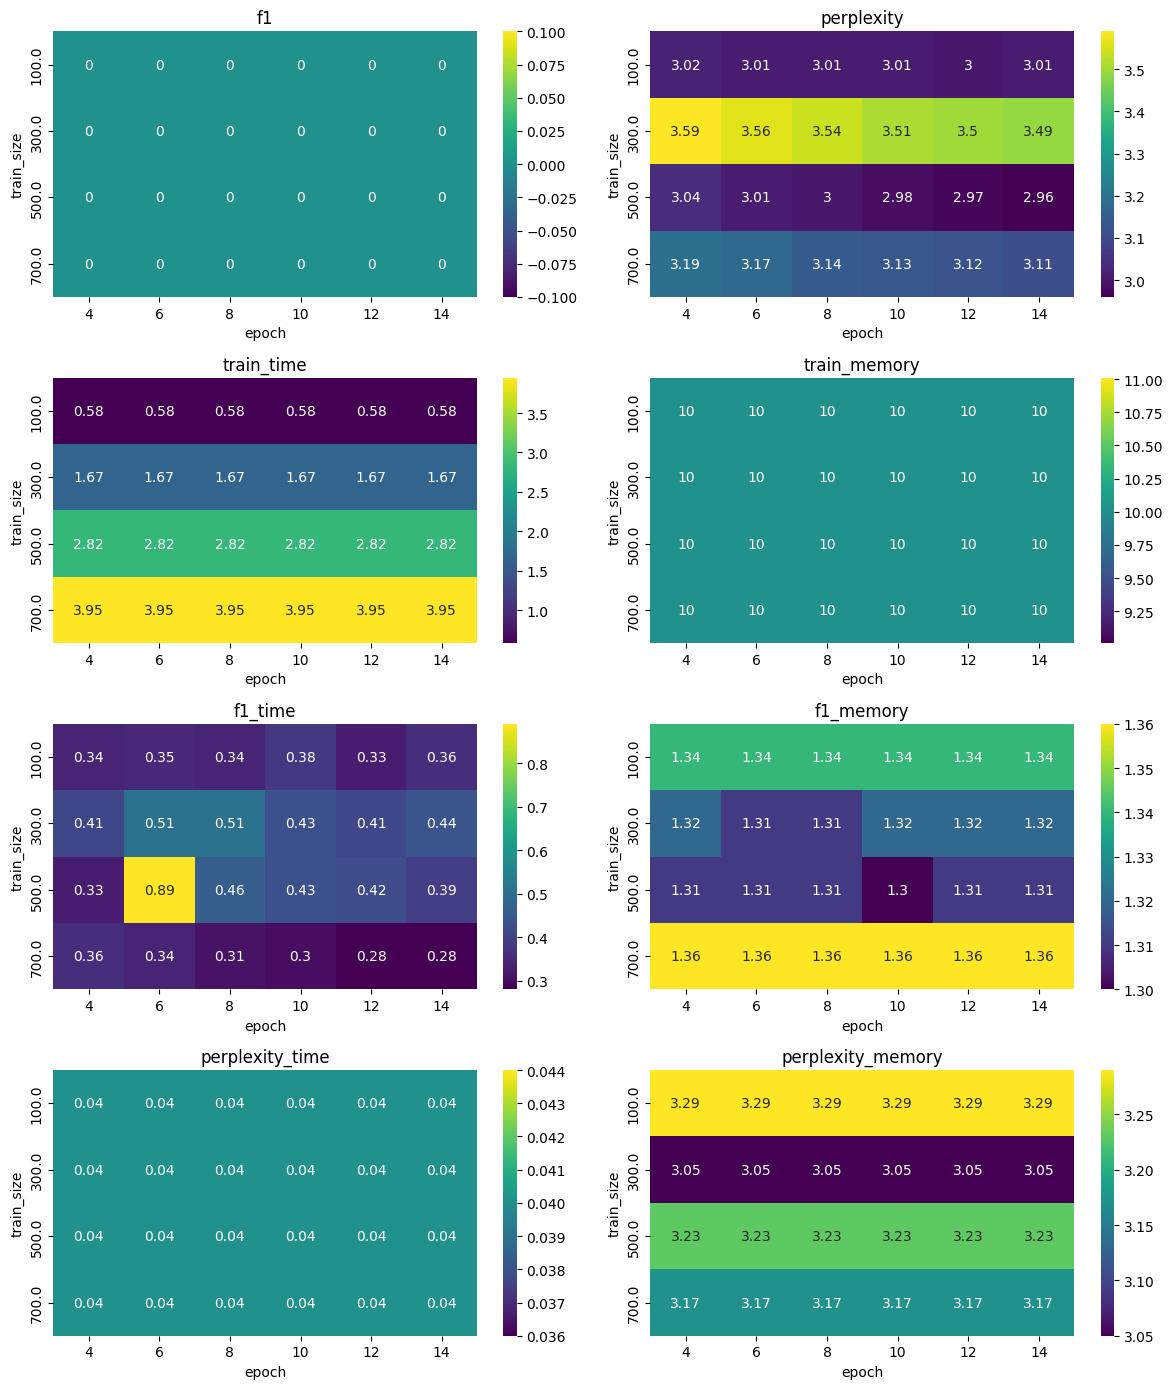

In [26]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

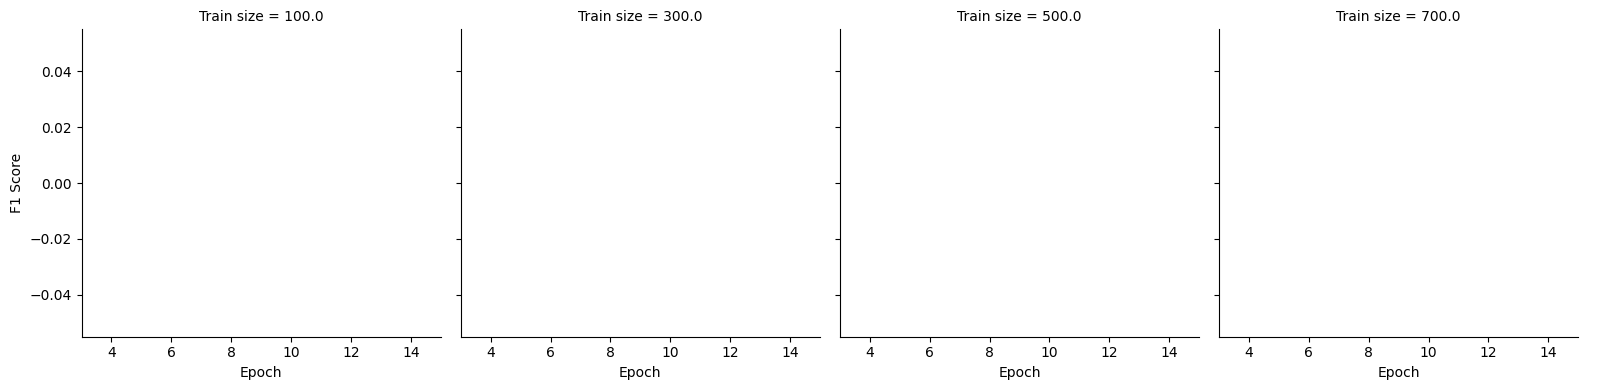

In [27]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

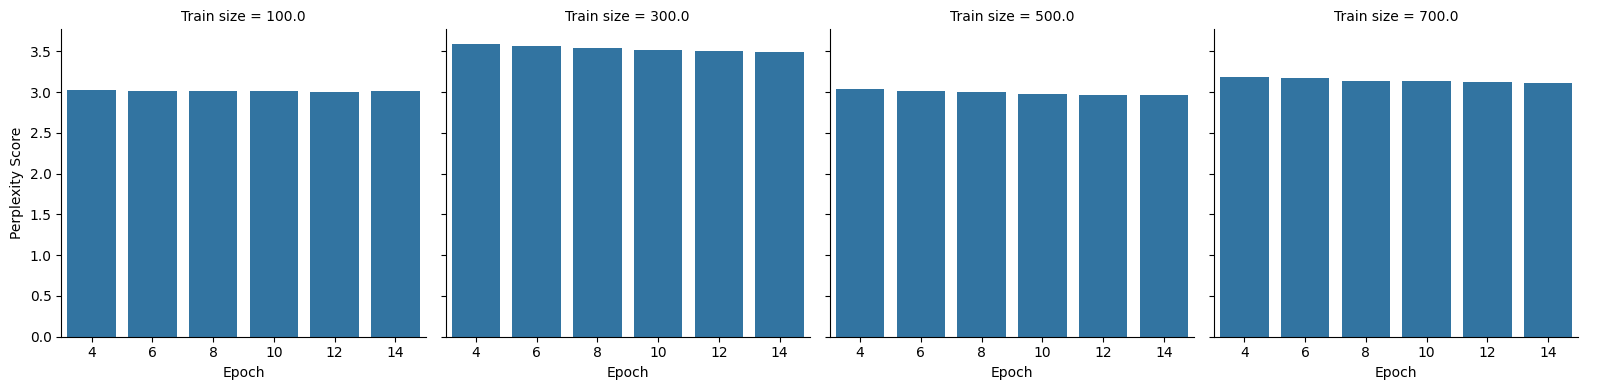

In [28]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

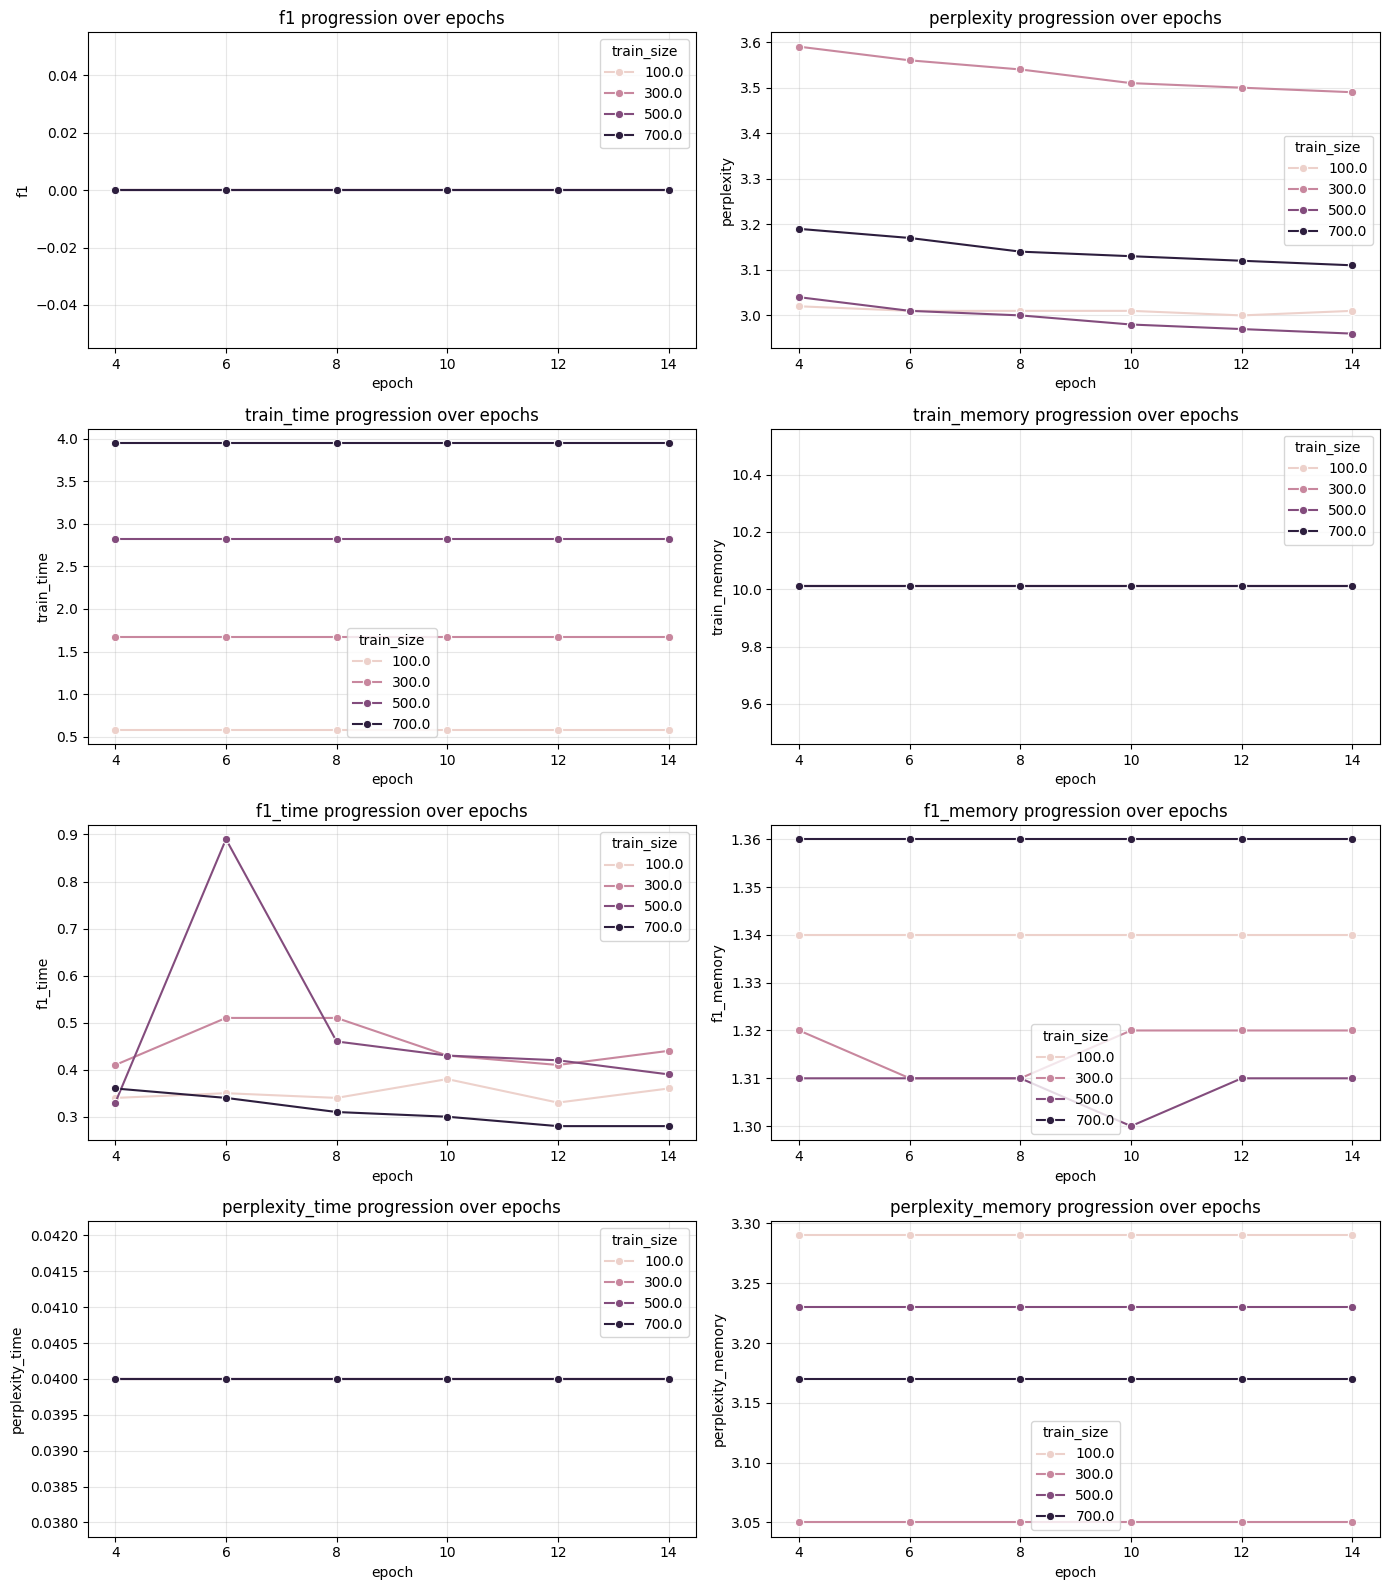

In [29]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# qwen lora gold 1.5b


In [30]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_1_5_first", "results_train_*.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100           18.464768                         3.76   
1         300           18.464768                         3.76   
2         500           18.464768                         3.76   
3         700           18.464768                         3.76   

   train_time_min  train_peak_memory_gb    f1  evaluate_f1_time_min  \
0            1.57                  7.74  0.78                  3.22   
1            4.63                  7.74  0.82                  2.75   
2            7.70                  7.74  0.79                  2.82   
3           10.91                  7.74  0.77                  2.59   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        4.33        1.44                           0.1  ...   
1                        4.25        1.47                           0.1  ...   
2                        4.22        1.39                           0.1  

In [38]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [39]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.72,1.45,3.01,4.33,0.1,5.45,1.57,7.74
1,100.0,6,0.79,1.44,2.94,4.33,0.1,5.45,1.57,7.74
2,100.0,8,0.81,1.44,3.07,4.33,0.1,5.45,1.57,7.74
3,100.0,10,0.78,1.44,3.22,4.33,0.1,5.45,1.57,7.74
4,300.0,4,0.83,1.42,2.75,4.25,0.1,5.20,4.63,7.74
5,300.0,6,0.78,1.43,3.43,4.25,0.1,5.20,4.63,7.74
6,300.0,8,0.85,1.45,2.73,4.25,0.1,5.20,4.63,7.74
7,300.0,10,0.82,1.47,2.75,4.25,0.1,5.20,4.63,7.74
8,500.0,4,0.88,1.33,2.73,4.22,0.1,5.39,7.70,7.74
9,500.0,6,0.88,1.35,2.79,4.22,0.1,5.39,7.70,7.74


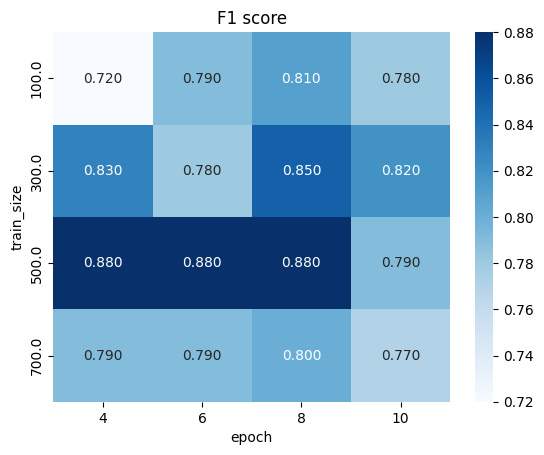

In [40]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


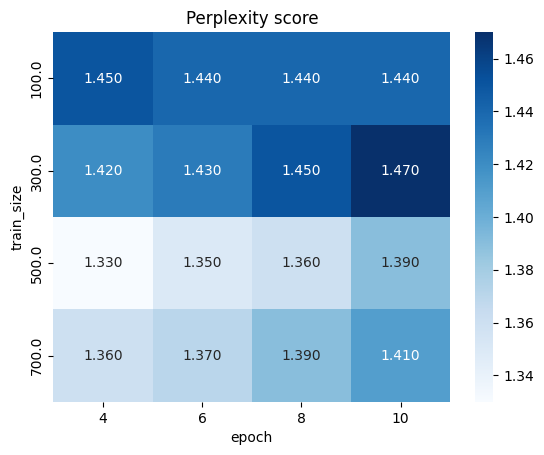

In [41]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


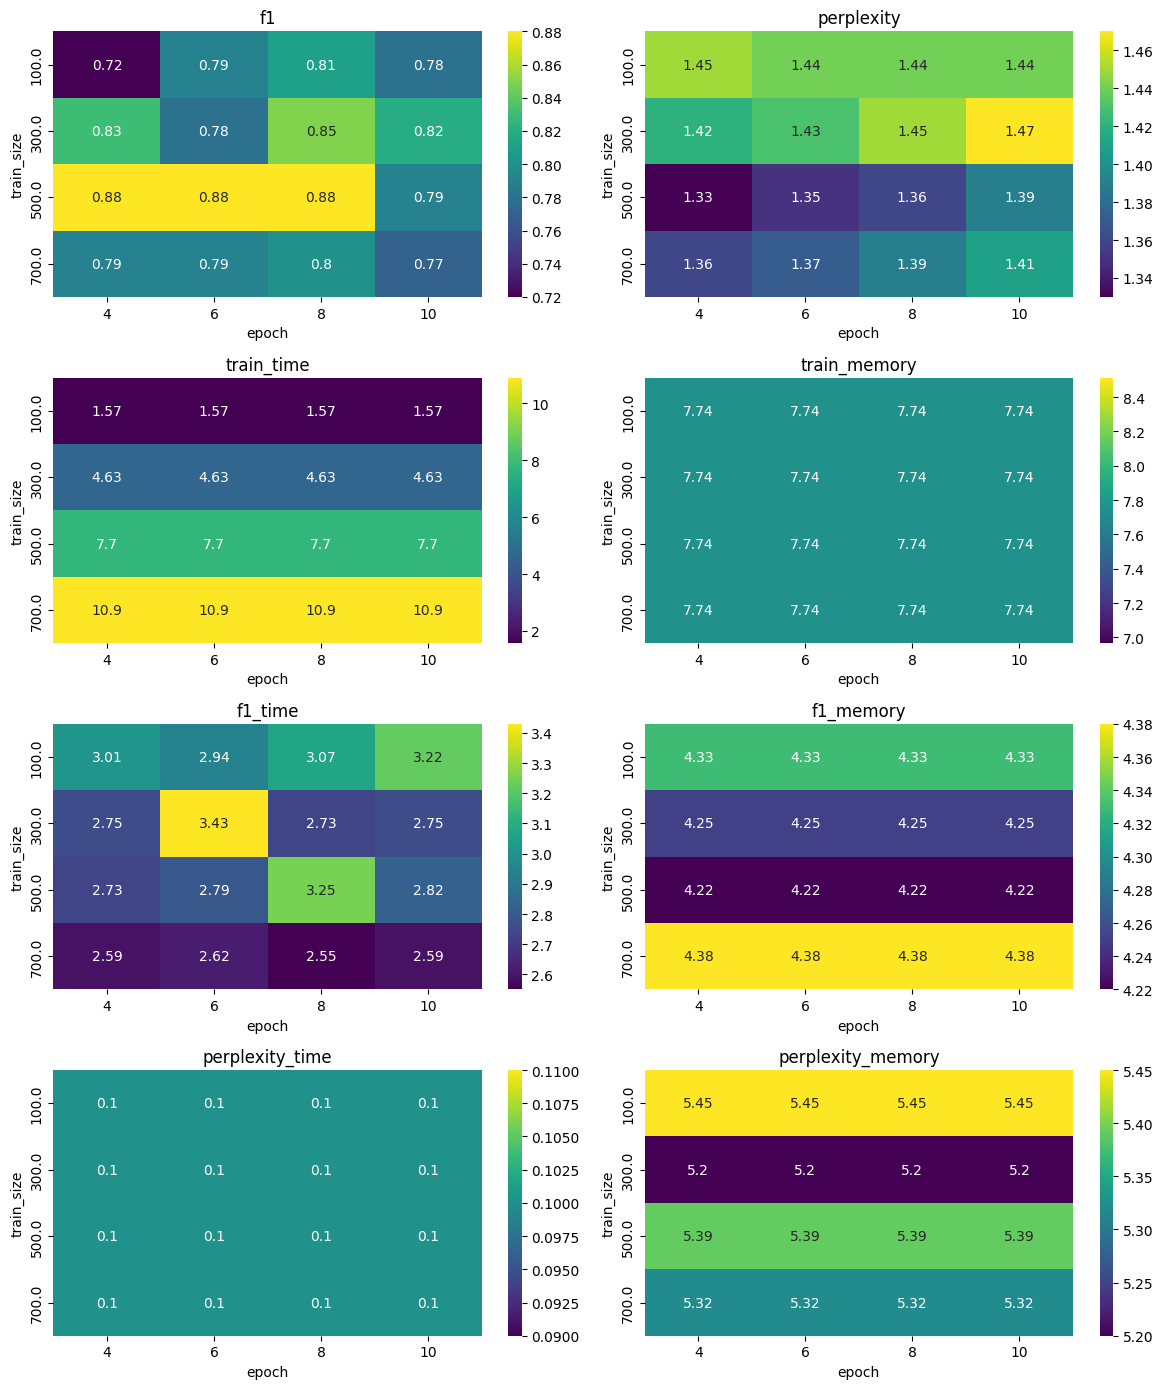

In [42]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

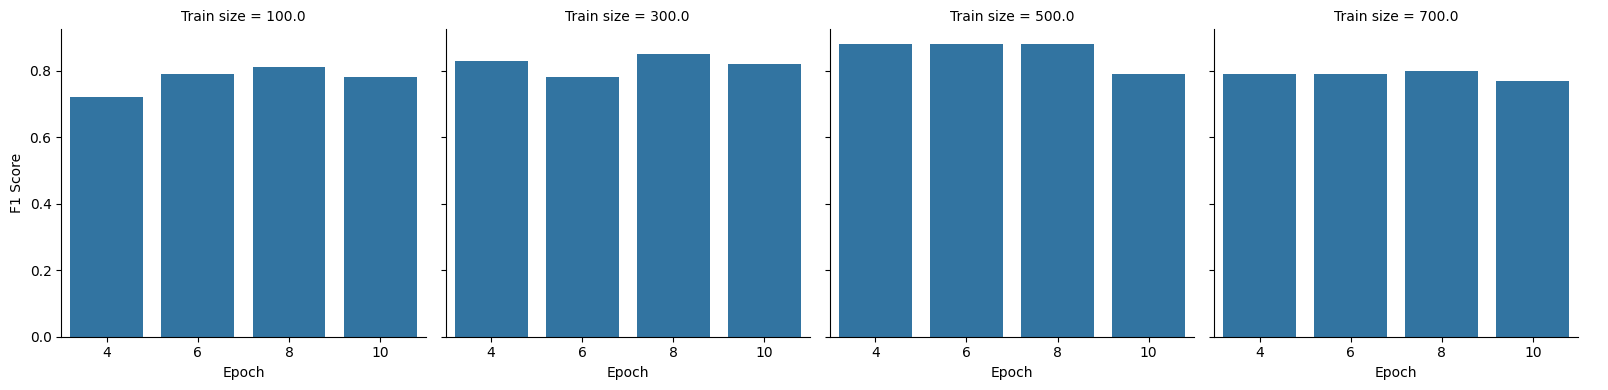

In [43]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

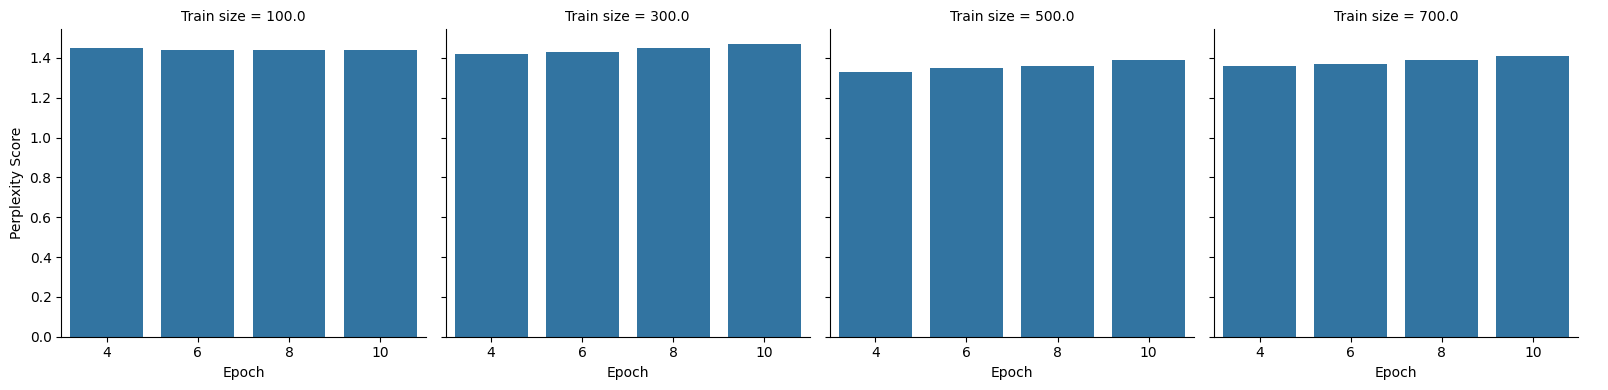

In [44]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

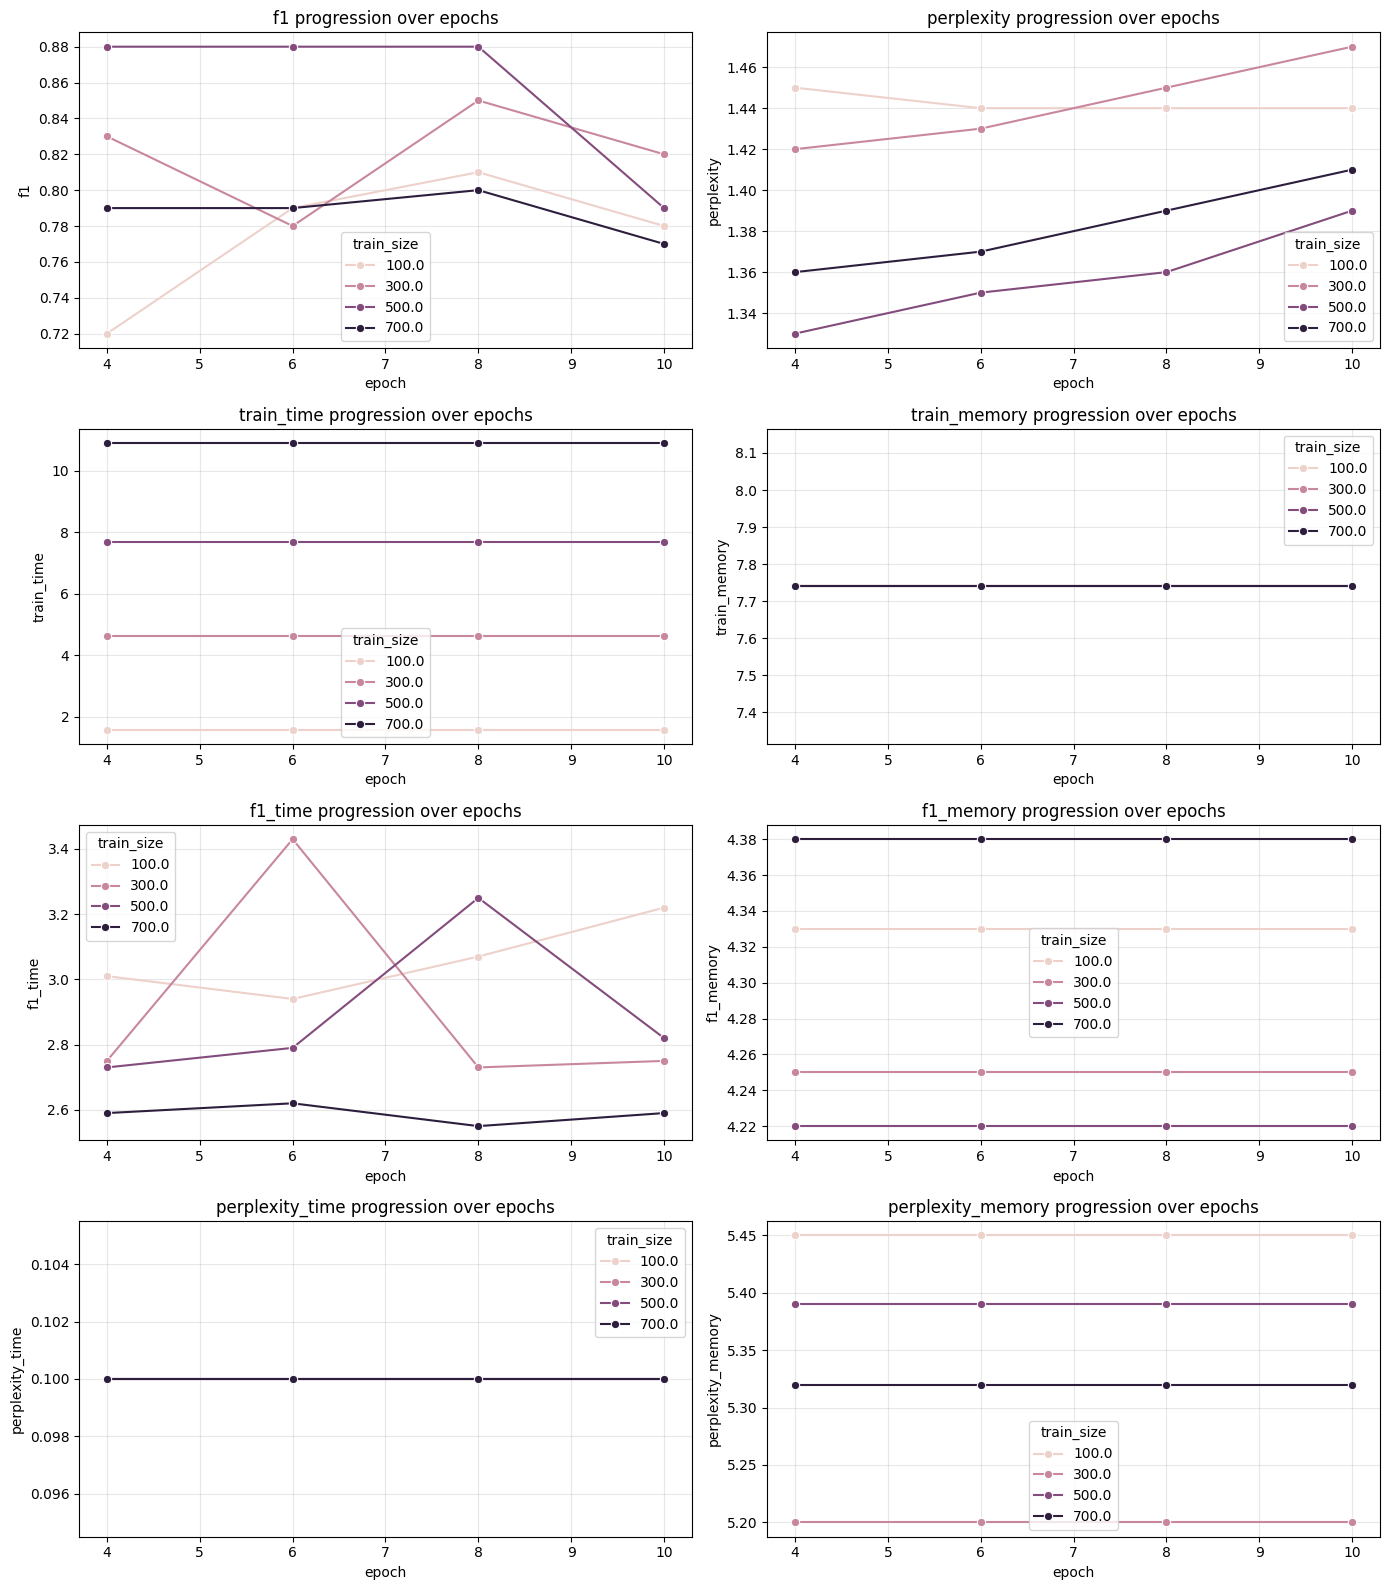

In [45]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()